# Разведочный анализ кредитного датасета (LendingClub)

**Цель:** изучить структуру кредитного портфеля, очистить данные от малоинформативных признаков и выявить закономерности, полезные для последующего скорингового моделирования.

**Данные:** `LoansData.csv` — выгрузка по выданным займам (суммы, процентные ставки, статусы, характеристики заёмщиков). 

**Структура ноутбука:**
1. Загрузка и очистка данных
2. Распределения ключевых признаков
3. Описательные статистики
4. Поиск выбросов (боксплоты)
5. Признаки в разрезе статуса займа
6. Корреляционный анализ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Загрузка и очистка данных

Убираем три группы малоинформативных данных:
- **редкие типы заявок** — оставляем только те, на которые приходится ≥ 5% наблюдений;
- **признаки с большим числом пропусков** — доля `NaN` > 20%;
- **низковариативные признаки** — менее 10 уникальных значений, одно из которых занимает > 80%.

In [3]:
df = pd.read_csv("LoansData.csv", low_memory=False)
print(f"Исходный размер: {df.shape[0]:,} строк x {df.shape[1]} столбцов")

# 1.1 Доли типов заявок
app_type_share = df["application_type"].value_counts(normalize=True)
print("\nДоли типов заявок:")
print(app_type_share)

# 1.2 Признаки с высокой долей пропусков (> 20%)
missing_ratio = df.isnull().mean()
print(f"\nБольше всего пропусков: '{missing_ratio.idxmax()}' "
      f"({missing_ratio.max():.1%})")
high_missing_cols = missing_ratio[missing_ratio > 0.2].index.tolist()

# 1.3 Низковариативные признаки (< 10 уникальных значений, одно занимает > 80%)
low_variance_cols = []
for col in df.columns:
    if df[col].nunique() < 10:
        dominant_share = df[col].value_counts(normalize=True).iloc[0]
        if dominant_share > 0.8:
            low_variance_cols.append(col)

print(f"\nК удалению по доле пропусков (>20%):       {len(high_missing_cols)}")
print(f"К удалению как низковариативные (>80%):     {len(low_variance_cols)}")

# 1.4 Применяем фильтры
df = df.groupby("application_type").filter(lambda x: len(x) / len(df) >= 0.05)
cols_to_drop = sorted(set(high_missing_cols + low_variance_cols))
df = df.drop(columns=cols_to_drop, errors="ignore")

print(f"\nРазмер после очистки: {df.shape[0]:,} строк x {df.shape[1]} столбцов")

Исходный размер: 887,379 строк x 72 столбцов

Доли типов заявок:
application_type
INDIVIDUAL    0.999424
JOINT         0.000576
Name: proportion, dtype: float64

Больше всего пропусков: 'dti_joint' (99.9%)

К удалению по доле пропусков (>20%):       21
К удалению как низковариативные (>80%):     4

Размер после очистки: 886,868 строк x 47 столбцов


## 2. Распределения ключевых признаков

Смотрим распределения сумм, ставок, платежей и категориальных признаков, чтобы понять масштаб, асимметрию и доминирующие категории.

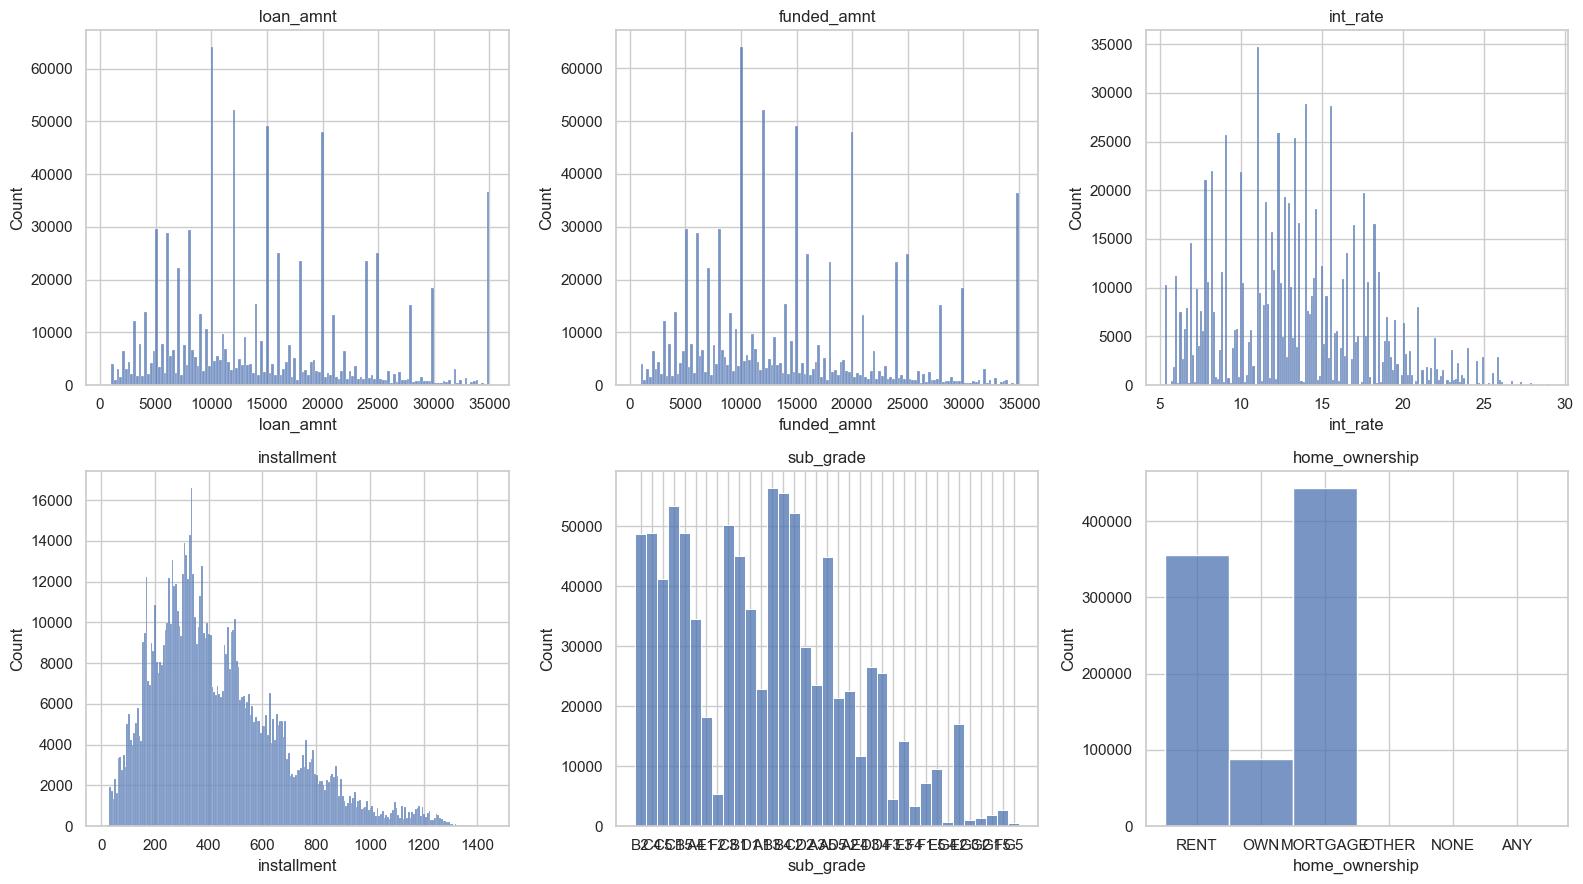

In [4]:
dist_features = ["loan_amnt", "funded_amnt", "int_rate",
                 "installment", "sub_grade", "home_ownership"]
dist_features = [c for c in dist_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), dist_features):
    sns.histplot(data=df, x=col, ax=ax)
    ax.set_title(col)

# Скрываем лишние пустые оси, если признаков меньше, чем ячеек сетки
for ax in axes.ravel()[len(dist_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 3. Описательные статистики

Ключевые квантили и разброс по сумме займа (`loan_amnt`).

In [5]:
loan_amnt_stats = df["loan_amnt"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])
print("Сумма займа (loan_amnt):")
print(loan_amnt_stats.round(2))

Сумма займа (loan_amnt):
count    886868.00
mean      14752.59
std        8434.36
min         500.00
1%         1800.00
5%         3600.00
50%       13000.00
95%       32000.00
99%       35000.00
max       35000.00
Name: loan_amnt, dtype: float64


## 4. Поиск выбросов

Боксплоты числовых признаков для оценки выбросов и асимметрии распределений.

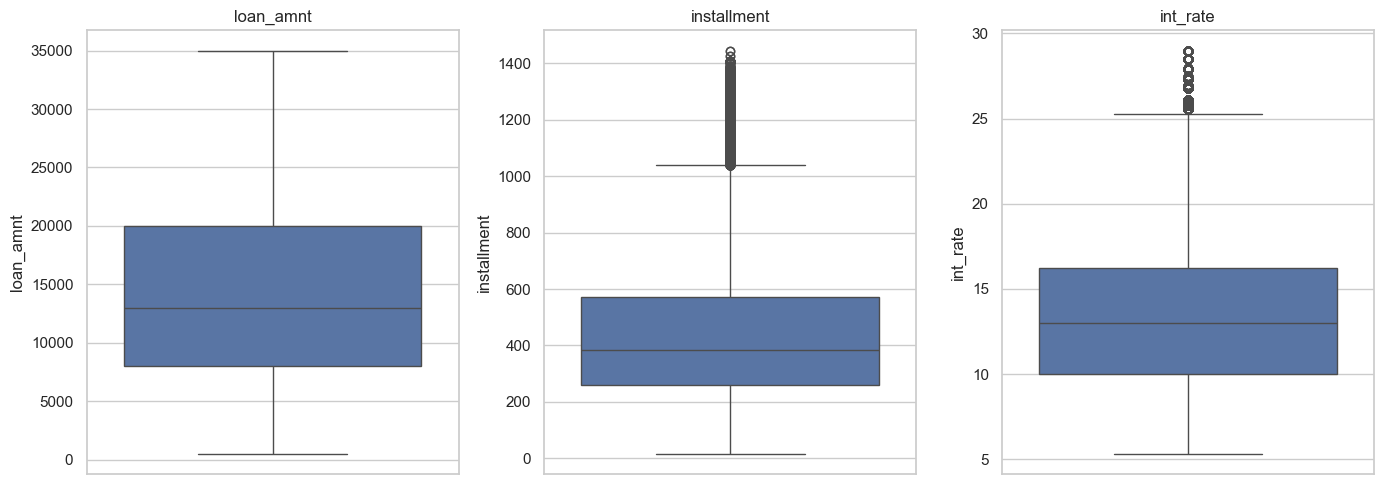

In [6]:
box_features = ["loan_amnt", "installment", "int_rate"]
box_features = [c for c in box_features if c in df.columns]

fig, axes = plt.subplots(1, len(box_features), figsize=(14, 5))
for ax, col in zip(np.atleast_1d(axes), box_features):
    sns.boxplot(y=col, data=df, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 5. Признаки в разрезе статуса займа

Сравниваем распределения сумм, платежей, ставок и средний годовой доход между статусами займа (`loan_status`). Заметные различия — первый сигнал потенциальной предиктивной силы признака.

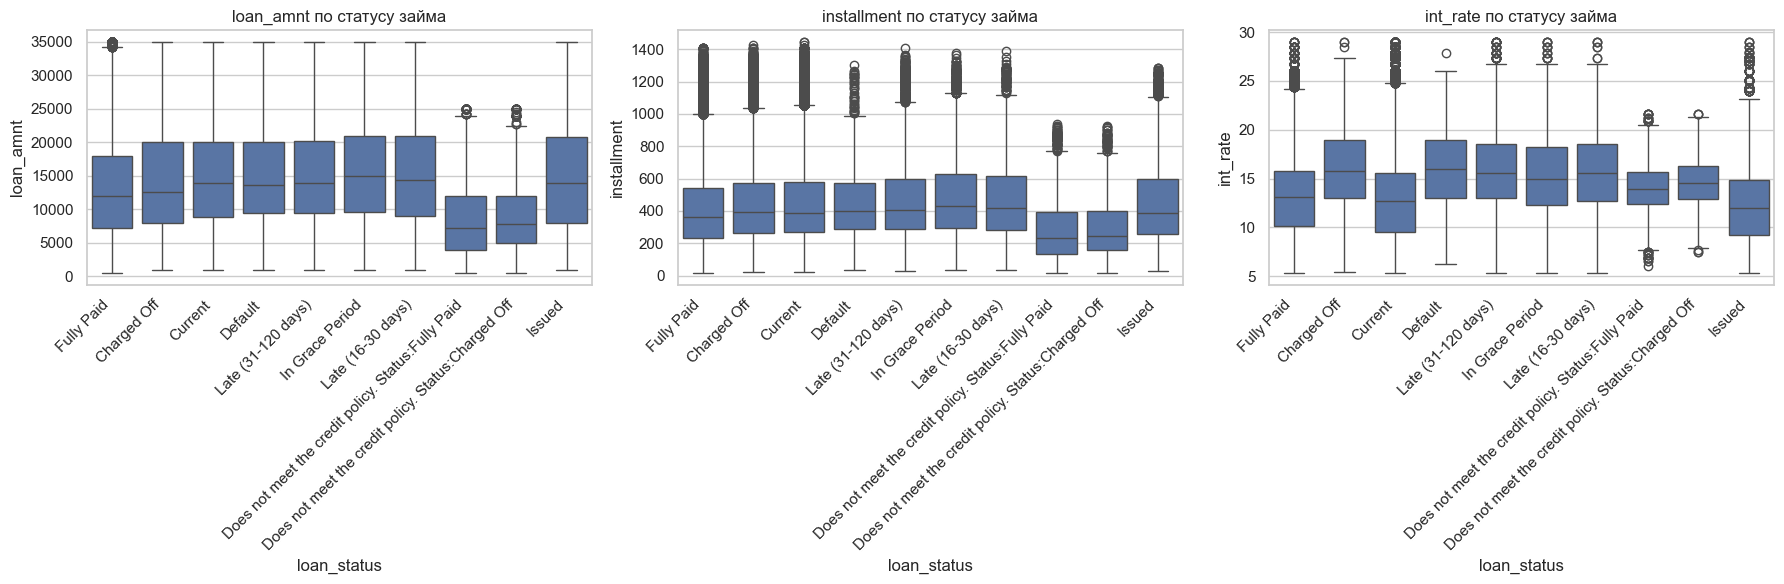

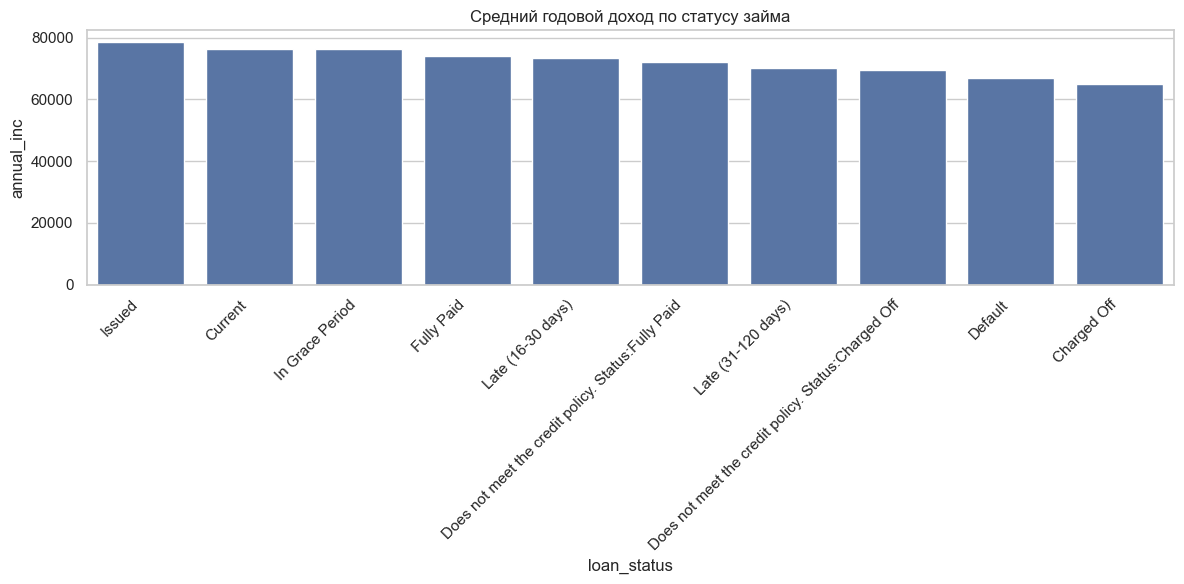

In [7]:
status_features = ["loan_amnt", "installment", "int_rate"]
status_features = [c for c in status_features if c in df.columns]

fig, axes = plt.subplots(1, len(status_features), figsize=(18, 6))
for ax, col in zip(np.atleast_1d(axes), status_features):
    sns.boxplot(x="loan_status", y=col, data=df, ax=ax)
    ax.set_title(f"{col} по статусу займа")
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

plt.tight_layout()
plt.show()

# Средний годовой доход по статусу займа
income_by_status = (
    df.groupby("loan_status", as_index=False)["annual_inc"]
      .mean()
      .sort_values("annual_inc", ascending=False)
)
plt.figure(figsize=(12, 6))
sns.barplot(x="loan_status", y="annual_inc", data=income_by_status)
plt.xticks(rotation=45, ha="right")
plt.title("Средний годовой доход по статусу займа")
plt.tight_layout()
plt.show()

## 6. Корреляционный анализ

Корреляции между числовыми признаками и связь суммы займа с суммарными выплатами.

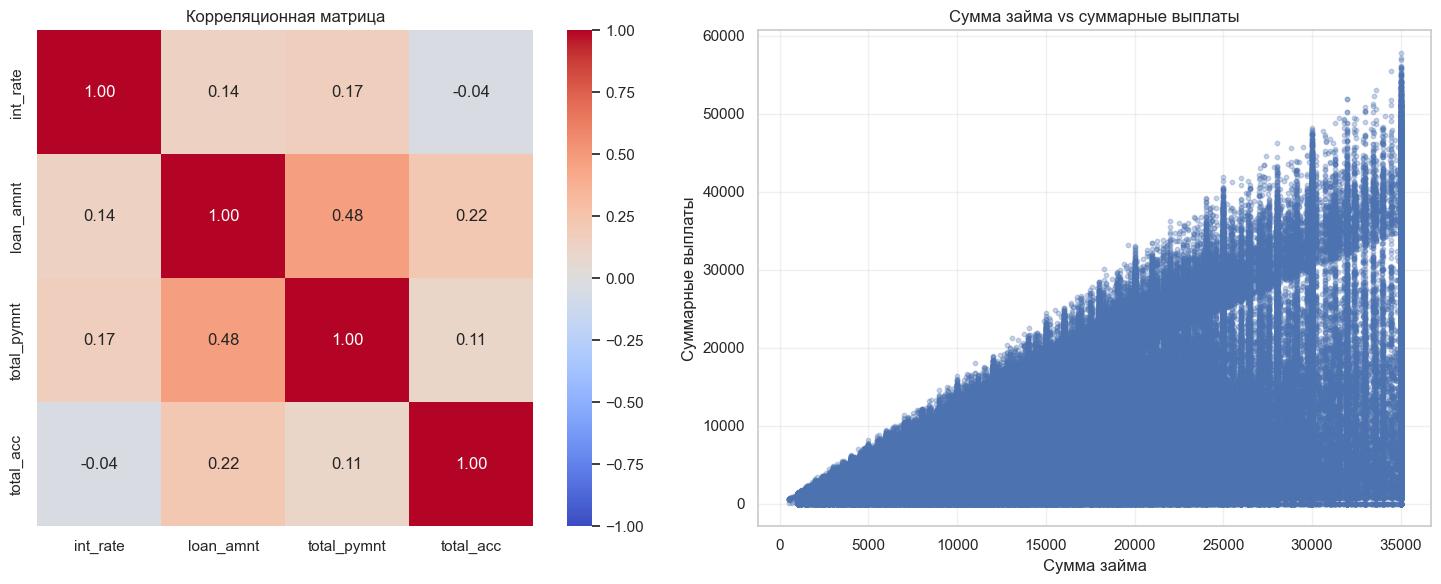

In [8]:
import matplotlib as mpl
mpl.rcParams["agg.path.chunksize"] = 10000  # ускоряет отрисовку плотного scatter

corr_features = ["int_rate", "loan_amnt", "total_pymnt", "total_acc"]
corr_features = [c for c in corr_features if c in df.columns]
correlation_matrix = df[corr_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title("Корреляционная матрица")

axes[1].scatter(df["loan_amnt"], df["total_pymnt"], alpha=0.3, s=10)
axes[1].set_xlabel("Сумма займа")
axes[1].set_ylabel("Суммарные выплаты")
axes[1].set_title("Сумма займа vs суммарные выплаты")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()